Скачиваем все необходимые библиотеки

In [23]:
%pip install pandas
%pip install torch
%pip install sklearn
%pip install pymorphy3
%pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Импортируем и сокращаем названия для использования

In [24]:
import pandas as pd
import torch as th
import torch.nn as nn
import torch.optim as optim
import sklearn as sk
from sklearn.linear_model import LogisticRegression
import pymorphy3
import re

Переменной dt с помощью pandas даем json файл с нашими данными (прописываем lines=True, для того что бы он читал документ построчно, иначе просто сломается) 

отдельно загружаем тест и трейн

In [25]:
dt_train = pd.read_json("train.jsonl", lines=True)
dt_test = pd.read_json("test.jsonl", lines=True)

Выведем наш файл для проверки,видно,что у нас есть всего 4 колонки, идеальный баланс классов (1:1:1),а так же текст,который на данный момент очень грязный, теперь нам нужно его почистить

In [26]:
print (dt_train.info())
print(dt_train['label'].value_counts())
print(dt_train['text'].iloc[0]) 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          10500 non-null  int64 
 1   text        10500 non-null  object
 2   label       10500 non-null  int64 
 3   label_text  10500 non-null  object
dtypes: int64(2), object(2)
memory usage: 328.3+ KB
None
label
2    3500
0    3500
1    3500
Name: count, dtype: int64
Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.
«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.
Сюжет
В ленте динам

из pymorhy3 достаем класс который может рабоать с русским языком,затем созадем функцию в которой будем чистить язык,переводим все в нижний регистр,затем с помощью re.sub(найти и заменить) мы ищем все,что не буквы и не пробел (r'[^а-яА-ЯёЁ ]) заменяя это все на пустоту, затем разбиение на токены (в этом случае по словам через split), созадем список куда будем кидать уже готовые слова, запускаем цикл который проходит по словам нормализует их и кидает в наш список, (normal_form = morph.parse(word)[0].normal_form), по кускам (morph.parse(word)) разбивает слово на список вариантов отсортированных по наиболее вероятный, нам логично нужен самый главный по этому из этого списка мы достаем первый ([0]), normal_form приводит наше слово в его "начальную" форму, затем уже готовое слово кидаем в наш список,но наши модельки со списками работать не будут,нам нужны строчки поэтому мы возвращаем в конце функции список который склеивает все в ожну строку и разделяет пробелами, в конце можем глянуть,что все работает, выводим чистый текст из нашей таблицы и выводим тот же текст,который питон проганяет сначала через нашу функцию очистки, видно,что все отлично сработало,а значит можно применить это ко всем нашим данным

In [27]:
morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    text = text.lower()
    text = re.sub(r'[^а-яА-ЯёЁ ]', '', text)
    words = text.split()


    clean_words = []
    for word in words:
        normal_form = morph.parse(word)[0].normal_form
        clean_words.append(normal_form)
    return ' '.join(clean_words)


print(dt_train['text'].iloc[0]) 
print(lemmatize_text(dt_train['text'].iloc[0]))



dt_train['cleaned_text'] = dt_train['text'].apply(lemmatize_text)
dt_test['cleaned_text'] = dt_test['text'].apply(lemmatize_text)

Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.
«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.
Сюжет
В ленте динамичный, а главное интересный и захватывающий сюжет, что в последнее время не так уж и часто. Новый Холмс не поход классический образ представленный в картинах Игоря Масленникова, но это не портит его образ. Он больше подобен на Тони Старку из «Железного человека» или Грегори Хаусу из сериала «Доктор Хаус». Как и они, он весьма харизматичен, слегка безумен, но гениален в своём любимом деле.
На первый взгляд сюжет портит сверхъестественное восстание из могилы лорда 

импортируем из sklearn TF-IDF затем даем ее переменной с параметрами (min_df=3) означает в каком минимуме документах должно быть слово (в нашем случае как минимум в 3), а (max_df) - говорит модели игнорировать слова выше процентного значения обозначающие нахождения во всех документах, (в нашем случае если больше чем в 90% то игнорируем), затем мы обучаем модельку и получаем матрицу размерностью 1500: "количество слов которые получила модель", !!Разбил на н-граммы,а не слова,матрица получилась больше,но и score увеличился с 0,59 до 0,62

Удалим стоп-слова добавим nltk
(упало до 0,6)

In [28]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words_ru = stopwords.words('russian')


tfidf = TfidfVectorizer(min_df=3, max_df=0.9, ngram_range=(1, 2), stop_words=stop_words_ru)

X_train = tfidf.fit_transform(dt_train['cleaned_text'])

X_test = tfidf.transform(dt_test['cleaned_text'])


print(X_train.shape)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(10500, 113658)


Устанавливаем правильные ответы

In [29]:
y_train = dt_train['label']
y_test = dt_test['label']

Для классификации можно выбрать логрег как идеальную простую модель,импортируем ее и передаем в переменную,обучаем на наших трейнах и выводим результат
1) получилось 0,59 (возможно стоит разбить на н-граммы)
2) после разбиения получилось получше 0,62 (нужно посмотреть на чем спотыкается и что не так со словами)
3) удалил стоп-слова,но почему то стало хуже 0,60 (нужно построить матрицу ошибок)
4) исправил ошибку,с не правильным разделением на train и test финальная метрика 0,67

In [30]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=19)


print("Начинаю обучение...")
model.fit(X_train, y_train)
print("Обучение завершено!")


accuracy = model.score(X_test, y_test)
print(f"Точность модели на тесте: {accuracy:.2f}")

Начинаю обучение...
Обучение завершено!
Точность модели на тесте: 0.67


Нужно посмотреть какие слова модель вообще воспринимает за положительные,а какие за негативные, сначала мы вытаскиваем из нашего TF-IDF список слов которые в нем есть, затем счиатаем коээфиценты наших слов, отнимаю у позитивных негативные, затем создаем таблицу, в первую колонку слово,во вторую его вес (чем больше вес тем позитивнее слово,чем меньше тем негативниее, посередине нейтральные слова), потом сортируем наши слова (ascending=False) по убыванию,то есть сверху самые лучшие, (ascending=True) сверху самые худшие веса, затем просто выводим это

Видно,что есть нормальные слова которые подходят,но есть стоп слова которые мешают и по сути не несут смысловой нагрузки по типу (он,ты,быть,на,бы и тд)


после удаления стоп-слов видно,что смысловая нагрузка слов стала больше,но модель все равно показывет себя чуть хуже


In [31]:
feature_names = tfidf.get_feature_names_out()


coefficients = model.coef_[2] - model.coef_[0]


words_df = pd.DataFrame({'слово': feature_names, 'вес': coefficients})


top_positive = words_df.sort_values(by='вес', ascending=False).head(15)
top_negative = words_df.sort_values(by='вес', ascending=True).head(15)

print("Слова позитива")
print(top_positive)

print("Слова негатива")
print(top_negative)

Слова позитива
               слово       вес
5942    великолепный  5.123984
33738         каждый  5.003993
70288      потрясать  4.356863
25539          жизнь  4.307543
61027          очень  4.193097
60023       отличный  3.856268
82771           свой  3.539262
23453           душа  3.424073
72002     прекрасный  3.343006
80835           роль  3.331614
107283       человек  3.225977
59973        отлично  3.115888
84364         сердце  3.073601
1856       атмосфера  3.032694
94900        сыграть  2.981020
Слова негатива
                 слово       вес
9703            вообще -4.695113
54215          никакой -4.581036
64405           плохой -4.078879
20002           деньга -3.844875
109871           шутка -3.691887
88555          снимать -3.580434
98624              увы -3.434157
59386   отвратительный -3.401778
54174            никак -3.274374
89891        создатель -3.228100
22           абсолютно -3.214342
81615          русский -3.211001
86091          скучный -3.105515
86436       

Создадим матрицу ошибок (на чем модель ошибается больше всего), импортируем, y_pred по сути ответы нашей модели по той части которую мы ей еще не показывали, затем матрицу с ответами моделями и правильными ответами, создаем холст, теперь подключаем seaborn для рисования, (сonf_matrix)-сама матрица, (annot=True)-цифры в квадратах,(fmt='d')- для нормального отображения цифр, (cmap='Reds')-просто цвет любой на выбор, xticklabels и  yticklabels это просто наши оси, затем подписываем оси и выводим саму таблицу

видно,что модель в основном ошибается на нейтральных словах и ей сложнее всего маркировать именно их

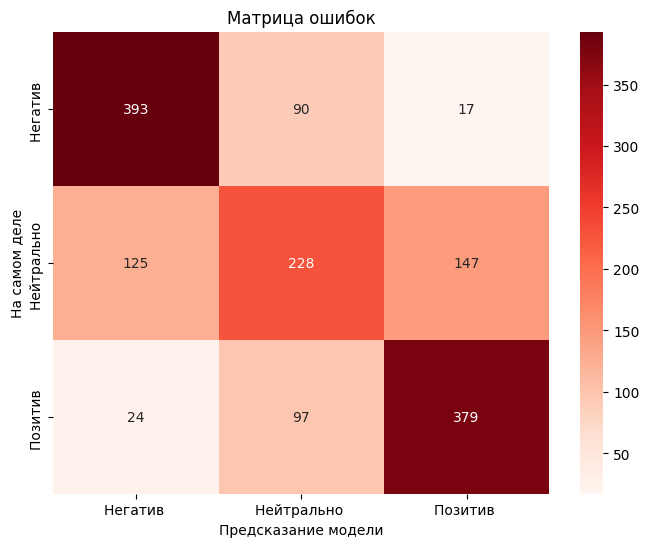

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


y_pred = model.predict(X_test)


conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))


sns.heatmap(conf_matrix, annot=True,fmt='d', cmap='Reds',
            xticklabels=['Негатив ', 'Нейтрально ', 'Позитив '],
            yticklabels=['Негатив ', 'Нейтрально ', 'Позитив '])

plt.xlabel('Предсказание модели')
plt.ylabel('На самом деле')
plt.title('Матрица ошибок')
plt.show()